In [138]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
%matplotlib inline

In [139]:
df = sns.load_dataset('iris')

In [140]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [141]:
class Model(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

In [142]:
# change the value of the species 
#load label encoder

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

In [143]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [144]:
df['species'].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

In [145]:
# train test split
from sklearn.model_selection import train_test_split

In [146]:
x =  df.drop('species', axis=1)  # x is features and y is the target variable
y  = df['species']

In [147]:
x = x.values   # x.values is used to convert the DataFrame into a NumPy array, which is often required for machine learning models that expect input in array format. This allows for efficient numerical computations and compatibility with various machine learning libraries. 
y = y.values

In [148]:
x

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [149]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [150]:
import torch
X_train = torch.FloatTensor(X_train)  # is convert the array into tensor
X_test = torch.FloatTensor(X_test)

In [151]:
y_train = torch.LongTensor(y_train)  # is convert the array into tensor
y_test = torch.LongTensor(y_test)

In [152]:
# set the creation model to measure the error

model = Model(input_size=4, hidden_size=16, output_size=3)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # updates the model parameters to minimize the loss function.

In [153]:
epochs = 100
losses = []

for i in range(epochs):
    y_pred = model.forward(X_train)
    loss = criterion(y_pred, y_train)
    losses.append(loss.item())
    if i % 10 == 0:
        print(f'Epoch {i} Loss: {loss.item()}')

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch 0 Loss: 1.4697202444076538
Epoch 10 Loss: 1.0141290426254272
Epoch 20 Loss: 0.8178813457489014
Epoch 30 Loss: 0.6120718121528625
Epoch 40 Loss: 0.47540897130966187
Epoch 50 Loss: 0.38471585512161255
Epoch 60 Loss: 0.30952951312065125
Epoch 70 Loss: 0.2467237412929535
Epoch 80 Loss: 0.19831779599189758
Epoch 90 Loss: 0.16283677518367767


Text(0, 0.5, 'Loss')

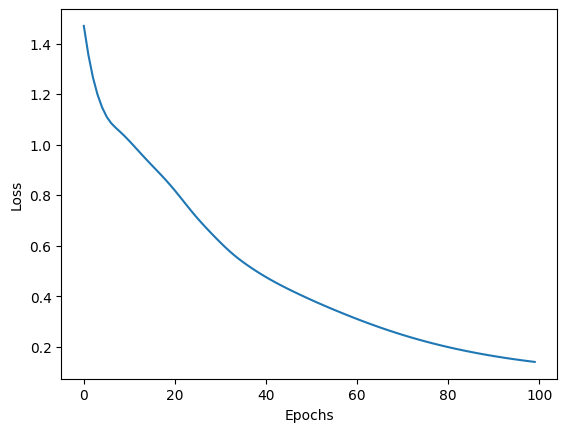

In [154]:
# Graph the loss over epochs
plt.plot(range(epochs), losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')